In [4]:
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau, spearmanr
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from cblearn import datasets

warnings.filterwarnings("ignore")

# Cấu hình đường dẫn src
ROOT = Path.cwd().parent
SRC_DIR = ROOT / "src"
DATA_DIR = ROOT / "data"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import utils as src_utils
import model as src_model

# Cấu hình Seed chuẩn để tái hiện
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.dpi"] = 120

In [5]:
def load_real_data():
    real_data = {}
    
    # 1. Zoo
    X_zoo, y_zoo = src_utils.load_zoo_features(DATA_DIR / "zoo/zoo.csv")
    real_data["zoo"] = (normalize(X_zoo), y_zoo)

    # 2. Glass
    X_glass, y_glass = src_utils.load_glass_features(DATA_DIR / "glass/glass.csv")
    real_data["glass"] = (normalize(X_glass), y_glass)

    # 3. MNIST (Chuẩn quy trình bài báo: Load test set -> t-SNE toàn bộ -> Sample 2000 -> Normalize)
    df_mnist = pd.read_csv(DATA_DIR / "mnist/mnist_test.csv")
    y_full = df_mnist["label"].to_numpy()
    X_full = df_mnist.drop(columns=["label"]).to_numpy(dtype=np.float32) / 255.0
    
    print("Đang chạy t-SNE giảm chiều cho toàn bộ tập MNIST Test...")
    X_full_2d = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, init="pca").fit_transform(X_full)
    
    # Random sample 200 examples per digit
    rng = np.random.default_rng(RANDOM_SEED)
    idx = []
    for c in range(10):
        ids = np.where(y_full == c)[0]
        pick = rng.choice(ids, size=200, replace=False)
        idx.append(pick)
    idx = np.concatenate(idx)
    
    X_mnist_2d = X_full_2d[idx]
    y_mnist = y_full[idx]
    
    # Normalize vào khoảng [-1, 1] như paper yêu cầu
    X_mnist_2d = X_mnist_2d / np.max(np.abs(X_mnist_2d))

    real_data["mnist"] = (X_mnist_2d, y_mnist)
    
    return real_data

def load_comparison_data():
    comp_data = {}
    comp_data["car"] = src_utils.load_car_triplets()
    comp_data["food"] = src_utils.get_cblearn_array(datasets.fetch_food_similarity)
    comp_data["vogue"] = src_utils.load_offline_triplets("vogue", DATA_DIR / "nature_and_vogue_triplets.zip")
    comp_data["nature"] = src_utils.load_offline_triplets("nature", DATA_DIR / "nature_and_vogue_triplets.zip")
    comp_data["imagenet"] = src_utils.load_imagenet_triplets()
    return comp_data

real_data = load_real_data()
comp_data = load_comparison_data()

Đang chạy t-SNE giảm chiều cho toàn bộ tập MNIST Test...


Quét SNR (Figure 1):   0%|          | 0/10 [00:00<?, ?it/s]

Quét k_factor (Table 1 & Figure 2):   0%|          | 0/10 [00:00<?, ?it/s]

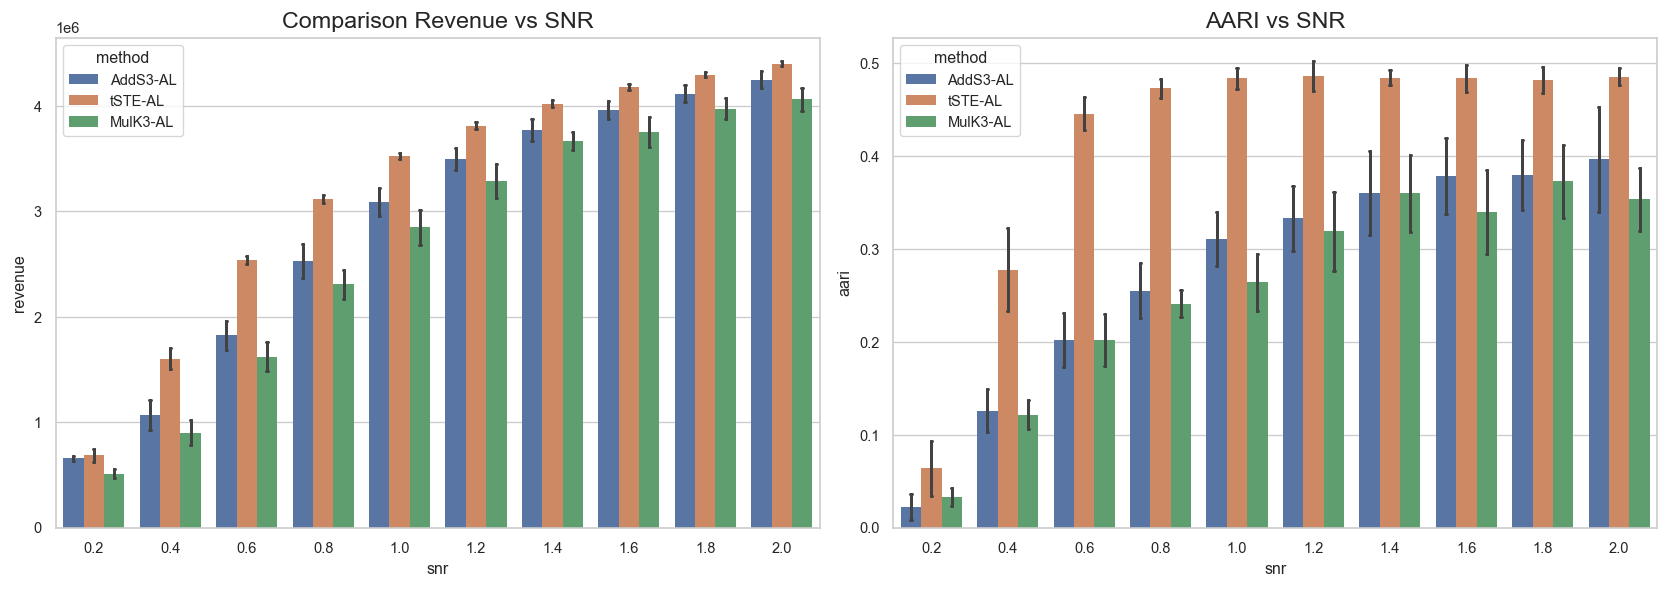

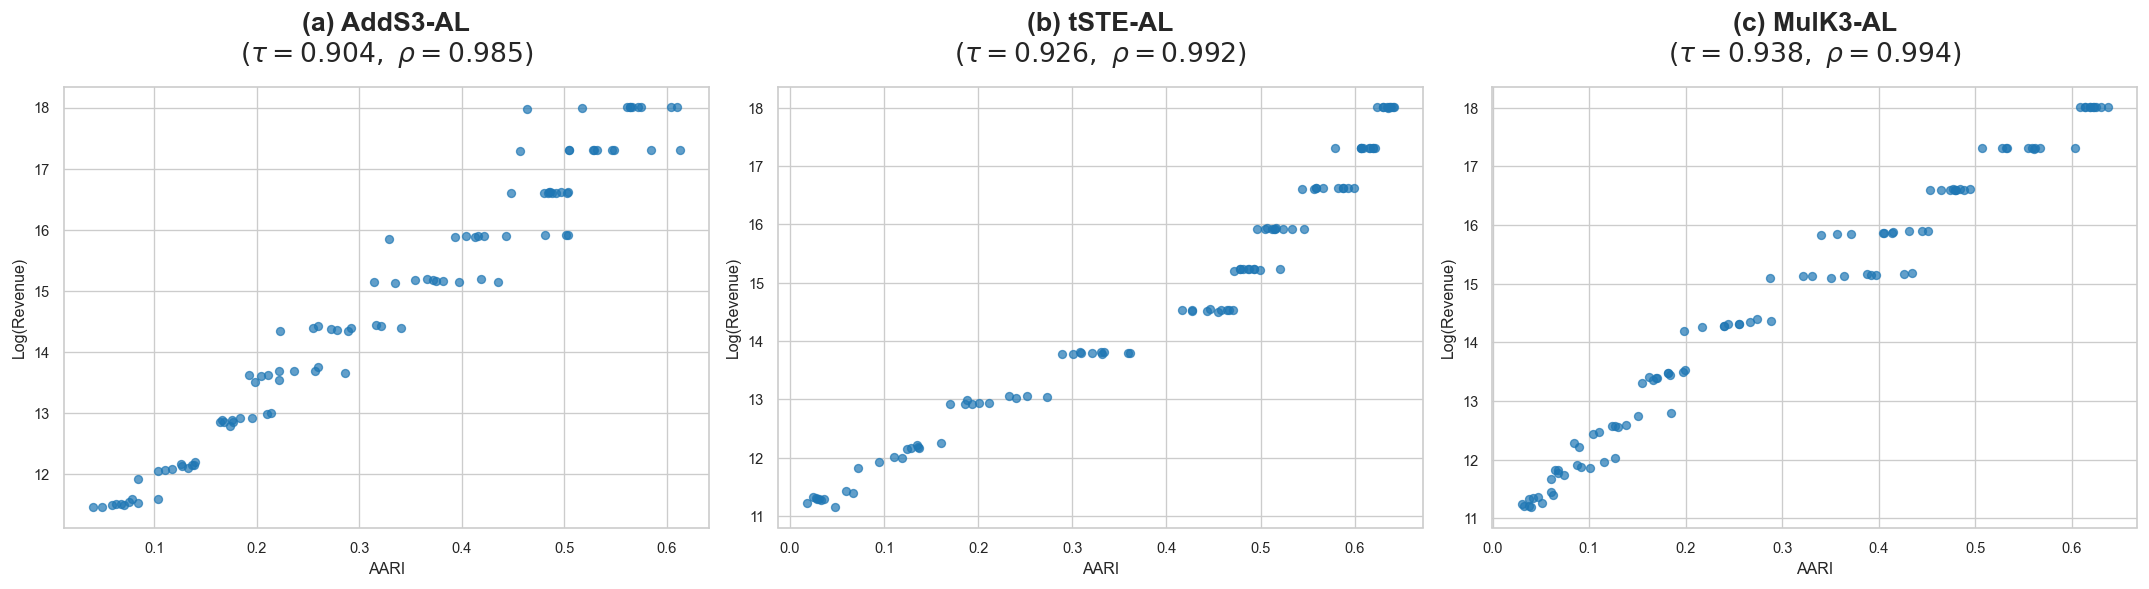

In [6]:
def make_planted_similarity_matrix(n_0=30, L=3, snr=1.0, random_state=42):
    rng = np.random.default_rng(random_state)
    n = n_0 * (2**L)  # n = 30 * 8 = 240
    
    mu = 0.8
    sigma = 0.1
    delta = snr * sigma  # SNR = delta / sigma
    
    # Khởi tạo ma trận S
    S = np.zeros((n, n))
    
    # Gán nhãn y (ground truth)
    y = np.repeat(np.arange(2**L), n_0)
    
    # Điền giá trị cho nửa trên của ma trận S
    for i in range(n):
        for j in range(i + 1, n):
            cluster_i, cluster_j = y[i], y[j]
            if cluster_i == cluster_j:
                l = L  # Cùng cụm
            else:
                diff = int(cluster_i ^ cluster_j)
                l = L - diff.bit_length()
                
            # Công thức mu_ij = mu - (L - l) * delta
            mu_ij = mu - (L - l) * delta
            
            # Sinh nhiễu Gaussian
            S[i, j] = rng.normal(loc=mu_ij, scale=sigma)
            S[j, i] = S[i, j] # Ma trận đối xứng
            
    return S, y

def build_triplets_from_S(S, k_factor=1.0, noise_rate=0.05, random_state=42):
    """Hàm helper sinh triplets TRỰC TIẾP từ ma trận S (bỏ qua bước tính Cosine)"""
    num_samples = int(k_factor * (len(S)**2))
    
    # Sinh triplets gốc
    triplets = src_utils.generate_triplets_from_similarity(S, num_samples=num_samples, random_state=random_state)
    
    # Lật nhãn (noise) 5% y như paper
    n_noisy = int(noise_rate * num_samples)
    if n_noisy > 0:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(num_samples, size=n_noisy, replace=False)
        triplets[idx, 1], triplets[idx, 2] = triplets[idx, 2].copy(), triplets[idx, 1].copy()
        
    return triplets


# --- 1. Chạy Figure 1 (Thay đổi SNR) ---
snr_values = np.round(np.arange(0.2, 2.1, 0.2), 1)
planted_rows_fig1 = []

for snr in tqdm(snr_values, desc="Quét SNR (Figure 1)"):
    for rep in range(10): # 10 runs
        S, y = make_planted_similarity_matrix(snr=snr, random_state=RANDOM_SEED + rep)
        T = build_triplets_from_S(S, k_factor=1.0, noise_rate=0.05, random_state=RANDOM_SEED + rep)
        
        for method, runner in {"AddS3-AL": src_model.adds3_al, "tSTE-AL": src_model.tste_al, "MulK3-AL": src_model.mulk3_al}.items():
            Z, _ = runner(len(S), T)
            planted_rows_fig1.append({"snr": snr, "method": method, "revenue": src_utils.triplet_revenue(Z, T), "aari": src_utils.compute_aari(Z, y, max_clusters=8)})

df_fig1 = pd.DataFrame(planted_rows_fig1)

# --- 2. Chạy Table 1 & Figure 2 (Cố định SNR=1.5, thay đổi k_factor) ---
k_factors = [16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]
table1_rows = []

for kf in tqdm(k_factors, desc="Quét k_factor (Table 1 & Figure 2)"):
    for rep in range(10): # 10 runs
        S, y = make_planted_similarity_matrix(snr=1.5, random_state=RANDOM_SEED + rep)
        # Đã sửa: Dùng helper function
        T = build_triplets_from_S(S, k_factor=kf, noise_rate=0.05, random_state=RANDOM_SEED + rep)
        
        for method, runner in {"AddS3-AL": src_model.adds3_al, "tSTE-AL": src_model.tste_al, "MulK3-AL": src_model.mulk3_al}.items():
            Z, _ = runner(len(S), T)
            table1_rows.append({"k_factor": kf, "method": method, "Revenue": src_utils.triplet_revenue(Z, T), "AARI": src_utils.compute_aari(Z, y, max_clusters=8)})

df_table1 = pd.DataFrame(table1_rows)

# ================= VẼ FIGURE 1 =================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_fig1, x="snr", y="revenue", hue="method", ax=axes[0], errorbar='sd', capsize=.05, edgecolor="none")
axes[0].set_title("Comparison Revenue vs SNR", fontsize=14)
sns.barplot(data=df_fig1, x="snr", y="aari", hue="method", ax=axes[1], errorbar='sd', capsize=.05, edgecolor="none")
axes[1].set_title("AARI vs SNR", fontsize=14)
plt.tight_layout()
plt.show()

# ================= VẼ FIGURE 2 =================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
for i, method in enumerate(["AddS3-AL", "tSTE-AL", "MulK3-AL"]):
    df_m = df_table1[df_table1["method"] == method]
    x, y_raw = df_m["AARI"].values, df_m["Revenue"].values
    y = np.log(np.maximum(y_raw, 1e-9))
    axes2[i].scatter(x, y, color="tab:blue", alpha=0.7)
    tau, rho = kendalltau(x, y)[0], spearmanr(x, y)[0]
    axes2[i].set(xlabel="AARI", ylabel="Log(Revenue)")
    axes2[i].set_title(f"({chr(97+i)}) {method}\n" + r"$(\tau = {:.3f},\ \rho = {:.3f})$".format(tau, rho), fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [9]:
df_table1 = pd.DataFrame(table1_rows)

# ================= HIỂN THỊ TABLE 1 (16n^2 -> n^2/32) =================
k_labels = ["16n^2", "8n^2", "4n^2", "2n^2", "n^2", "n^2/2", "n^2/4", "n^2/8", "n^2/16", "n^2/32"]
k_dict = dict(zip(k_factors, k_labels))

# Tính trung bình 10 runs
df_mean = df_table1.groupby(["k_factor", "method"])[["Revenue", "AARI"]].mean().reset_index()
df_mean["Number of triplets"] = df_mean["k_factor"].map(k_dict)

# Pivot bảng cho giống bài báo
pivot_t1 = df_mean.pivot(index=["k_factor", "Number of triplets"], columns="method", values=["Revenue", "AARI"])

# Sắp xếp lại cột và dòng
pivot_t1 = pivot_t1.swaplevel(0, 1, axis=1)[
    [("AddS3-AL", "Revenue"), ("AddS3-AL", "AARI"), 
     ("tSTE-AL", "Revenue"), ("tSTE-AL", "AARI"), 
     ("MulK3-AL", "Revenue"), ("MulK3-AL", "AARI")]
]
pivot_t1 = pivot_t1.sort_index(level=0, ascending=False).reset_index(level=0, drop=True)

# Format số liệu (Revenue dạng khoa học, AARI 3 chữ số thập phân)
for method in ["AddS3-AL", "tSTE-AL", "MulK3-AL"]:
    pivot_t1[(method, "Revenue")] = pivot_t1[(method, "Revenue")].apply(lambda x: f"{x:.3e}".replace("e+0", " × 10^").replace("e+", " × 10^").replace("e-", " × 10^-"))
    pivot_t1[(method, "AARI")] = pivot_t1[(method, "AARI")].apply(lambda x: f"{x:.3f}")

display(pivot_t1)
# =====================================================================



method                  AddS3-AL              tSTE-AL             MulK3-AL  \
                         Revenue   AARI       Revenue   AARI       Revenue   
Number of triplets                                                           
16n^2               6.584 × 10^7  0.560  6.620 × 10^7  0.635  6.616 × 10^7   
8n^2                3.289 × 10^7  0.535  3.305 × 10^7  0.610  3.291 × 10^7   
4n^2                1.632 × 10^7  0.487  1.650 × 10^7  0.573  1.620 × 10^7   
2n^2                7.991 × 10^6  0.431  8.229 × 10^6  0.517  7.813 × 10^6   
n^2                 3.855 × 10^6  0.375  4.106 × 10^6  0.489  3.754 × 10^6   
n^2/2               1.785 × 10^6  0.285  2.041 × 10^6  0.447  1.635 × 10^6   
n^2/4               8.432 × 10^5  0.229  9.783 × 10^5  0.324  6.788 × 10^5   
n^2/8               3.991 × 10^5  0.183  4.347 × 10^5  0.215  2.793 × 10^5   
n^2/16              1.813 × 10^5  0.122  1.793 × 10^5  0.122  1.406 × 10^5   
n^2/32              1.010 × 10^5  0.069  8.079 × 10^4  0.037  8.128 × 10^4   

method                     
                     AARI  
Number of triplets         
16n^2               0.621  
8n^2                0.551  
4n^2                0.477  
2n^2                0.404  
n^2                 0.369  
n^2/2               0.248  
n^2/4               0.177  
n^2/8               0.124  
n^2/16              0.086  
n^2/32              0.044

In [10]:
table3_rows = []

# 1. Thống kê Real Data
for name, (X, y) in real_data.items():
    n_obj = len(X)
    # Tính số Triplets theo cấu hình k_factor (Zoo k=10, Glass/MNIST k=1)
    k = 10.0 if name == "zoo" else 1.0
    n_triplets = int(k * (n_obj ** 2))
    
    table3_rows.append({
        "Dataset": name.capitalize(),
        "Query": "Cosine Similarity",
        "#Objects": n_obj,
        "#Triplets": n_triplets
    })

# 2. Thống kê Comparison Data
queries = {
    "car": "Most Central Triplet",
    "food": "Standard Triplet",
    "vogue": "Odd-out Triplet",
    "nature": "Odd-out Triplet",
    "imagenet": "Rank 2 from 8"
}

for name, T in comp_data.items():
    n_obj = int(np.asarray(T).max()) + 1
    n_triplets = len(T)
    
    table3_rows.append({
        "Dataset": name.capitalize(),
        "Query": queries.get(name, ""),
        "#Objects": n_obj,
        "#Triplets": n_triplets
    })

# Xuất bảng Table 3
df_table3 = pd.DataFrame(table3_rows)

display(df_table3)


,Dataset,Query,#Objects,#Triplets
0,Zoo,Cosine Similarity,100,100000
1,Glass,Cosine Similarity,214,45796
2,Mnist,Cosine Similarity,2000,4000000
3,Car,Most Central Triplet,60,14194
4,Food,Standard Triplet,100,190376
5,Vogue,Odd-out Triplet,60,2214
6,Nature,Odd-out Triplet,120,6710
7,Imagenet,Rank 2 from 8,1000,278003


In [7]:
rows_table2 = []
N_REPEATS = 10 

for dataset_name, (X, y) in real_data.items():
    n_obj = len(X)
    kf_target = 10.0 if dataset_name == "zoo" else 1.0 
    
    rev_acc = {m: [] for m in ["AddS3-AL", "tSTE-AL", "MulK3-AL", "AddS4-AL", "4K-AL", "Cosine-AL-T", "Cosine-AL-Q"]}

    for rep in tqdm(range(N_REPEATS), desc=f"{dataset_name.upper()}"):
        T = np.asarray(src_utils.build_cosine_triplets(X, k_factor=kf_target, noise_rate=0.05, random_state=RANDOM_SEED + rep), dtype=np.int64)
        Q = src_utils.triplets_to_quadruplets(T)

        Z_adds3, _ = src_model.adds3_al(n_obj, T)
        Z_tste, _  = src_model.tste_al(n_obj, T, n_components=10)
        Z_mulk3, _ = src_model.mulk3_al(n_obj, T)
        Z_adds4, _ = src_utils.run_adds4_al(n_obj, Q)
        Z_4k, _    = src_utils.run_4k_al(n_obj, Q)
        Z_cos      = src_utils.average_linkage_from_similarity(cosine_similarity(X))

        rev_acc["AddS3-AL"].append(src_utils.triplet_revenue(Z_adds3, T))
        rev_acc["tSTE-AL"].append(src_utils.triplet_revenue(Z_tste, T))
        rev_acc["MulK3-AL"].append(src_utils.triplet_revenue(Z_mulk3, T))
        rev_acc["Cosine-AL-T"].append(src_utils.triplet_revenue(Z_cos, T))
        rev_acc["AddS4-AL"].append(src_utils.quadruplet_revenue(Z_adds4, Q))
        rev_acc["4K-AL"].append(src_utils.quadruplet_revenue(Z_4k, Q))
        rev_acc["Cosine-AL-Q"].append(src_utils.quadruplet_revenue(Z_cos, Q))

    ds_cap = dataset_name.capitalize()
    for m in ["AddS3-AL", "tSTE-AL", "MulK3-AL"]: rows_table2.append({"Dataset": ds_cap, "Type": "Triplet", "Method": m, "Revenue": np.mean(rev_acc[m])})
    rows_table2.append({"Dataset": ds_cap, "Type": "Triplet", "Method": "Cosine-AL", "Revenue": np.mean(rev_acc["Cosine-AL-T"])})
    for m in ["AddS4-AL", "4K-AL"]: rows_table2.append({"Dataset": ds_cap, "Type": "Quadruplet", "Method": m, "Revenue": np.mean(rev_acc[m])})
    rows_table2.append({"Dataset": ds_cap, "Type": "Quadruplet", "Method": "Cosine-AL", "Revenue": np.mean(rev_acc["Cosine-AL-Q"])})


for dataset_name, T_raw in tqdm(comp_data.items(), desc="Comparison Datasets"):
    T = np.asarray(T_raw, dtype=np.int64)
    Q = src_utils.triplets_to_quadruplets(T)
    n_obj = int(T.max()) + 1
    ds_cap = dataset_name.capitalize()

    Z_adds3, _ = src_model.adds3_al(n_obj, T)
    Z_tste, _  = src_model.tste_al(n_obj, T, n_components=10)
    Z_mulk3, _ = src_model.mulk3_al(n_obj, T)
    Z_adds4, _ = src_utils.run_adds4_al(n_obj, Q)
    Z_4k, _    = src_utils.run_4k_al(n_obj, Q)

    rows_table2.append({"Dataset": ds_cap, "Type": "Triplet", "Method": "AddS3-AL", "Revenue": src_utils.triplet_revenue(Z_adds3, T)})
    rows_table2.append({"Dataset": ds_cap, "Type": "Triplet", "Method": "tSTE-AL", "Revenue": src_utils.triplet_revenue(Z_tste, T)})
    rows_table2.append({"Dataset": ds_cap, "Type": "Triplet", "Method": "MulK3-AL", "Revenue": src_utils.triplet_revenue(Z_mulk3, T)})
    rows_table2.append({"Dataset": ds_cap, "Type": "Triplet", "Method": "Cosine-AL", "Revenue": np.nan})
    rows_table2.append({"Dataset": ds_cap, "Type": "Quadruplet", "Method": "AddS4-AL", "Revenue": src_utils.quadruplet_revenue(Z_adds4, Q)})
    rows_table2.append({"Dataset": ds_cap, "Type": "Quadruplet", "Method": "4K-AL", "Revenue": src_utils.quadruplet_revenue(Z_4k, Q)})
    rows_table2.append({"Dataset": ds_cap, "Type": "Quadruplet", "Method": "Cosine-AL", "Revenue": np.nan})

# ================= FORMAT TABLE 2 =================
df_table2 = pd.DataFrame(rows_table2)
pivot_t2 = df_table2.pivot_table(index="Dataset", columns=["Type", "Method"], values="Revenue")
pivot_t2 = pivot_t2[[("Triplet", "AddS3-AL"), ("Triplet", "tSTE-AL"), ("Triplet", "MulK3-AL"), ("Triplet", "Cosine-AL"), 
                     ("Quadruplet", "AddS4-AL"), ("Quadruplet", "4K-AL"), ("Quadruplet", "Cosine-AL")]]
pivot_t2 = pivot_t2.reindex(["Zoo", "Glass", "Mnist", "Car", "Food", "Vogue", "Nature", "Imagenet"])

def format_sci(x): return "-" if pd.isna(x) else f"{x:.3e}".replace("e+0", " × 10^").replace("e+", " × 10^").replace("e-", " × 10^-")
for col in pivot_t2.columns: pivot_t2[col] = pivot_t2[col].apply(format_sci)

display(pivot_t2)

ZOO:   0%|          | 0/10 [00:00<?, ?it/s]

GLASS:   0%|          | 0/10 [00:00<?, ?it/s]

MNIST:   0%|          | 0/10 [00:00<?, ?it/s]

Comparison Datasets:   0%|          | 0/5 [00:00<?, ?it/s]

Type           Triplet                                            \
Method        AddS3-AL       tSTE-AL      MulK3-AL     Cosine-AL   
Dataset                                                            
Zoo       2.670 × 10^6  2.539 × 10^6  2.663 × 10^6  2.610 × 10^6   
Glass     2.077 × 10^6  1.869 × 10^6  1.792 × 10^6  2.006 × 10^6   
Mnist     1.911 × 10^9  1.890 × 10^9  1.283 × 10^9  2.051 × 10^9   
Car       3.708 × 10^4  2.877 × 10^4  3.563 × 10^4             -   
Food      6.051 × 10^6  6.080 × 10^6  6.206 × 10^6             -   
Vogue     2.307 × 10^4  1.877 × 10^4  1.687 × 10^4             -   
Nature    1.533 × 10^5  5.042 × 10^4  5.105 × 10^4             -   
Imagenet  6.075 × 10^7  1.083 × 10^7  4.592 × 10^7             -   

Type        Quadruplet                              
Method        AddS4-AL         4K-AL     Cosine-AL  
Dataset                                             
Zoo       2.667 × 10^6  1.781 × 10^3  2.610 × 10^6  
Glass     2.013 × 10^6  1.251 × 10^6  2.006 × 10^6  
Mnist     1.894 × 10^9  1.451 × 10^9  2.051 × 10^9  
Car       2.981 × 10^4  2.789 × 10^3             -  
Food      6.036 × 10^6  3.560 × 10^6             -  
Vogue     2.143 × 10^4  1.003 × 10^4             -  
Nature    6.440 × 10^4  2.344 × 10^4             -  
Imagenet  5.961 × 10^7  4.554 × 10^7             -